In [1]:
import os
from pathlib import Path
os.chdir(Path.cwd().parent)
print(f"Current working directory: {Path.cwd()}")

Current working directory: k:\PythonWork\downscaling\Kaya_downscaling


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

from affine import Affine
from rasterio.features import rasterize
from rasterio.crs import CRS
import geopandas as gpd
import xarray as xr
import rioxarray as rxr

import downscaling.read_process_grid_data as process_grid_data

Initializing logging system with log directory: log/reading_processing_data/local


In [3]:
project_dir = Path.cwd()
print(f"Current working directory: {project_dir}")

Current working directory: k:\PythonWork\downscaling\Kaya_downscaling


In [4]:
dir_urban = project_dir / "data" / "processed" / "DLL"
path_urban = dir_urban / "urban_classification_years.parquet"
gdf_urban_classification = gpd.read_parquet(path_urban)
print(gdf_urban_classification.dtypes)

UID                        int64
GDAM_id                   object
GADM_level               float64
Country                   object
GID_0                     object
State/province            object
GID_1                     object
County/district           object
GID_2                     object
Commune/municipality      object
GID_3                     object
admin_level_4             object
GID_4                     object
admin_level_5             object
GID_5                     object
geometry                geometry
cluster_2015             float64
cluster_2020             float64
cluster_2030             float64
cluster_2040             float64
cluster_2050             float64
cluster_2060             float64
cluster_2070             float64
cluster_2080             float64
cluster_2090             float64
cluster_2100             float64
dtype: object


In [5]:
file_path_file_model_grid_regions = project_dir / "data" / "processed" / "GADM" / "IMAGE_ScenarioMIP_GADM_regions_raster_6_00_arcmin.nc"
xr_IAM_regions_grid = xr.open_dataset(file_path_file_model_grid_regions, decode_coords="all")
xr_IAM_regions_grid

<xarray.Dataset> Size: 104MB
Dimensions:          (y: 1800, x: 3600)
Coordinates:
  * x                (x) float64 29kB -179.9 -179.8 -179.8 ... 179.8 179.9 180.0
  * y                (y) float64 14kB 89.95 89.85 89.75 ... -89.75 -89.85 -89.95
    spatial_ref      int64 8B ...
Data variables:
    country_id_GADM  (y, x) float64 52MB ...
    region_number    (y, x) int64 52MB ...

In [6]:
def factor_from_arcmin(transform, target_arcmin):
    px_x = abs(transform.a) * 60.0
    px_y = abs(transform.e) * 60.0
    if not np.isclose(px_x, px_y):
        raise ValueError(f"Non-square pixels ({px_x:.4f} vs {px_y:.4f} arcmin); one factor cannot serve both axes")
    px_arcmin = px_x
    if target_arcmin > px_arcmin:
        raise ValueError(f"Target {target_arcmin} arcmin is coarser than the grid ({px_arcmin:.4f} arcmin)")
    factor = max(1, int(round(px_arcmin / target_arcmin)))
    effective = px_arcmin / factor
    if not np.isclose(effective, target_arcmin):
        print(f"{target_arcmin} arcmin is not an exact divisor of {px_arcmin:.4f}; using factor={factor} -> {effective:.4f} arcmin")
    return factor

In [9]:
def build_output_grid(bounds, arcmin):
    left, bottom, right, top = bounds
    deg = arcmin / 60.0
    nx_f, ny_f = (right - left) / deg, (top - bottom) / deg
    nx, ny = round(nx_f), round(ny_f)
    if not (np.isclose(nx_f, nx) and np.isclose(ny_f, ny)):
        raise ValueError(f"{arcmin} arcmin does not divide the extent into whole pixels ({nx_f:.4f} x {ny_f:.4f})")
    transform = Affine(deg, 0.0, left, 0.0, -deg, top)
    x = left + (np.arange(nx) + 0.5) * deg
    y = top - (np.arange(ny) + 0.5) * deg
    return transform, ny, nx, x, y

def urban_shapes(gdf, col, gadm_level=None):
    mask = gdf[col].eq(1) & gdf.geometry.notna()
    if gadm_level is not None:
        mask &= gdf["GADM_level"].eq(gadm_level)
    return [(geom, 1) for geom in gdf.loc[mask, "geometry"].values]

def raster_fraction(shapes, transform_out, ny, nx, oversample, row_block):
    frac = np.zeros((ny, nx), dtype="float32")
    if len(shapes) == 0:
        return frac
    n = oversample * oversample
    for r0 in range(0, ny, row_block):
        r1 = min(r0 + row_block, ny)
        shp = ((r1 - r0) * oversample, nx * oversample)
        win = transform_out * Affine.translation(0, r0) * Affine.scale(1.0 / oversample)
        fine = rasterize(shapes, out_shape=shp, transform=win, fill=0, all_touched=False, dtype="uint8")
        frac[r0:r1] = fine.reshape(r1 - r0, oversample, nx, oversample).sum(axis=(1, 3), dtype="float32") / n
        del fine
    return frac


In [10]:
grid = xr_IAM_regions_grid
gdf = gdf_urban_classification

grid_crs = grid.rio.crs
if grid_crs is None:
    wkt = grid["spatial_ref"].attrs.get("crs_wkt") or grid["spatial_ref"].attrs.get("spatial_ref")
    grid_crs = CRS.from_wkt(wkt) if wkt else CRS.from_epsg(4326)
    print(f"grid.rio.crs was None; using {grid_crs}")

# --- parameters ---
output_arcmin = 6.0        # 6 arcmin = 0.1 deg
oversample = 10            # sub-cells per output pixel per axis
mem_bytes = 128 * 1024**2  # transient fine-array budget per tile (two masks now share it)
gadm_level = None          # e.g. 3.0 to pin urban clusters to one non-overlapping level

# CRS: recover from spatial_ref, since grid.rio.crs comes back None here
grid = grid.rio.write_crs(grid["spatial_ref"].attrs["crs_wkt"])
grid_crs = grid.rio.crs
if gdf.crs is not None and gdf.crs != grid_crs:
    gdf = gdf.to_crs(grid_crs)

transform_out, ny, nx, x_out, y_out = build_output_grid(grid.rio.bounds(), output_arcmin)
row_block = min(ny, max(1, int(mem_bytes / (oversample * nx * oversample))))  # one fine mask per tile now

cluster_cols = sorted((c for c in gdf.columns if c.startswith("cluster_")),
                      key=lambda c: int(c.split("_")[1]))
years = [int(c.split("_")[1]) for c in cluster_cols]

land_shapes = [(geom, 1) for geom in gdf.loc[gdf.geometry.notna(), "geometry"].values]
land_frac = raster_fraction(land_shapes, transform_out, ny, nx, oversample, row_block)  # once, reused for every year
ocean_2d = (100.0 * (1.0 - land_frac)).astype("float32")                                # identical every year

perc_urban = np.empty((len(cluster_cols), ny, nx), dtype="float32")
perc_rural = np.empty((len(cluster_cols), ny, nx), dtype="float32")
perc_ocean = np.empty((len(cluster_cols), ny, nx), dtype="float32")
for i, col in enumerate(cluster_cols):
    u = raster_fraction(urban_shapes(gdf, col, gadm_level), transform_out, ny, nx, oversample, row_block)
    u = np.minimum(u, land_frac)  # defensive; urban is already a subset of land
    perc_urban[i] = 100.0 * u
    perc_rural[i] = 100.0 * (land_frac - u)
    perc_ocean[i] = ocean_2d

cat = grid[["country_id_GADM", "region_number"]].reindex(y=y_out, x=x_out, method="nearest")

xr_IAM_regions_urban_rural_grid = xr.Dataset(
    {"perc_urban": (("time", "y", "x"), perc_urban),
     "perc_rural": (("time", "y", "x"), perc_rural),
     "perc_ocean": (("time", "y", "x"), perc_ocean),
     "country_id_GADM": (("y", "x"), cat["country_id_GADM"].values),
     "region_number": (("y", "x"), cat["region_number"].values)},
    coords={"time": ("time", np.array(years, dtype="int16")), "y": y_out, "x": x_out})
xr_IAM_regions_urban_rural_grid = xr_IAM_regions_urban_rural_grid.rio.write_crs(grid_crs)
xr_IAM_regions_urban_rural_grid.to_netcdf(project_dir / "data" / "processed" / "models" / "IMAGE_ScenarioMIP_GADM_urban_rural_raster_6_00_arcmin.nc", mode="w", format="NETCDF4", engine="netcdf4")

In [11]:
profile = "base_run"
model = "IMAGE_ScenarioMIP"
scenario = "IMAGE 3.4_Medium - SSP2"
convergence_year = 2150
gross_net = "net"
model_scenario_convergence_year = f"{model}_{scenario}_conv_year_{convergence_year}_{gross_net}"
dir_processed = project_dir / "data" / "processed" / profile / model_scenario_convergence_year
em_harmonised_file = dir_processed / f"Emissions_CO2_Excl_shipping_aviation_AFOLU_harmonised_SSP2.nc"

xr_emissions = xr.open_dataset(em_harmonised_file, decode_coords="all")
print(xr_emissions)

<xarray.Dataset> Size: 940MB
Dimensions:                                     (time: 12, y: 1800, x: 3600)
Coordinates:
  * x                                           (x) float64 29kB -179.9 ... 1...
  * y                                           (y) float64 14kB 89.95 ... -8...
  * time                                        (time) int64 96B 2020 ... 2100
    spatial_ref                                 int64 8B ...
    region_number                               (y, x) int8 6MB ...
Data variables:
    Emissions_CO2_Excl_shipping_aviation_AFOLU  (time, y, x) float64 622MB ...
    correction_factor                           (time, y, x) float32 311MB ...


In [20]:
def align_to_grid(da, target):
    same = (da["y"].size == target["y"].size and da["x"].size == target["x"].size
            and np.allclose(da["y"], target["y"]) and np.allclose(da["x"], target["x"]))
    if not same:
        raise ValueError("xr_emissions is not on the ds_out grid; regrid it conservatively (sum-preserving) first")
    return da

def classify(perc_urban, perc_ocean, urban_t, ocean_t):
    is_ocean = perc_ocean >= ocean_t
    is_urban = (perc_urban >= urban_t) & (perc_ocean < ocean_t)
    return xr.where(is_ocean, 0, xr.where(is_urban, 2, 1)).astype("int8")  # 0 ocean, 1 rural, 2 urban

def mask_to_emitting(cls, emis):
    emitting = emis.notnull() & (emis != 0)
    return cls.where(emitting)  # non-emitting cells become NaN

def crop(da, lon_min, lon_max, lat_min, lat_max):
    return da.sel(x=slice(lon_min, lon_max), y=slice(lat_max, lat_min))  # y descending: north first

def plot_classes(cls_emitting, year):
    cmap = ListedColormap(["#3b6ea5", "#8bbf6b", "#c0392b"])  # ocean, rural, urban
    norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)
    fig, ax = plt.subplots(figsize=(12, 6))
    img = cls_emitting.plot.pcolormesh(ax=ax, x="x", y="y", cmap=cmap, norm=norm, add_colorbar=False)
    bar = fig.colorbar(img, ax=ax, ticks=[0, 1, 2], shrink=0.6)
    bar.ax.set_yticklabels(["ocean", "rural", "urban"])
    ax.set_title(f"Emitting-cell classification, {year}")
    return fig

def emissions_by_class(emis, cls):
    labels = {2: "urban", 1: "rural", 0: "ocean"}
    return {name: float(emis.where(cls == value).sum(skipna=True)) for value, name in labels.items()}

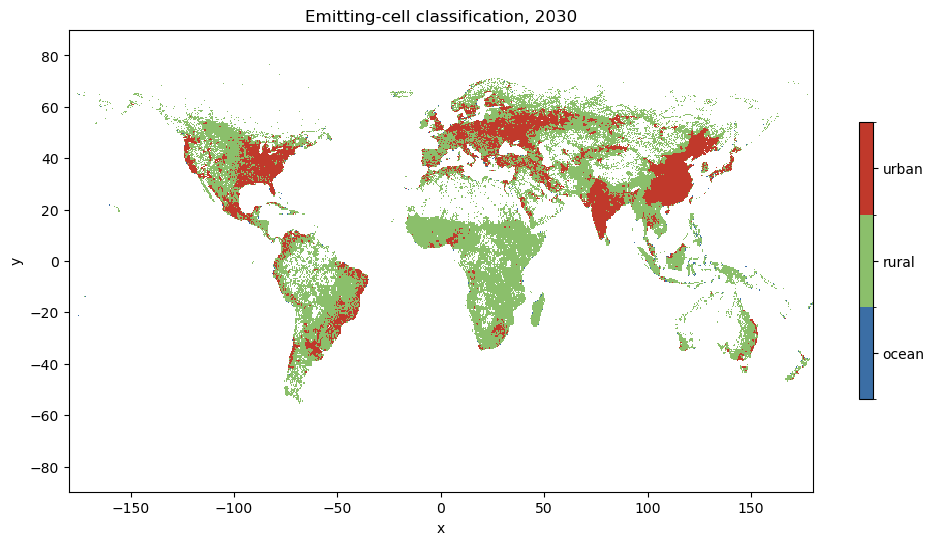

{'urban': 3446945568.6913924, 'rural': 1147894220.9227161, 'ocean': 13854457.585292373}
check: 4608694247.199401 vs 35431915044.691696


In [18]:
YEAR = 2030
EM_VAR = "Emissions_CO2_Excl_shipping_aviation_AFOLU"
URBAN_T = 70
OCEAN_T = 90

emis = align_to_grid(xr_emissions[EM_VAR].sel(time=YEAR), xr_IAM_regions_urban_rural_grid)
cls = classify(xr_IAM_regions_urban_rural_grid["perc_urban"].sel(time=YEAR), xr_IAM_regions_urban_rural_grid["perc_ocean"].sel(time=YEAR), URBAN_T, OCEAN_T)

# 1. map of the classification over emitting cells
fig = plot_classes(mask_to_emitting(cls, emis), YEAR)
plt.show()

# 2. global emissions summed per class
totals = emissions_by_class(emis, cls)
print(totals)
print("check:", sum(totals.values()), "vs", float(emis.sum(skipna=True)))

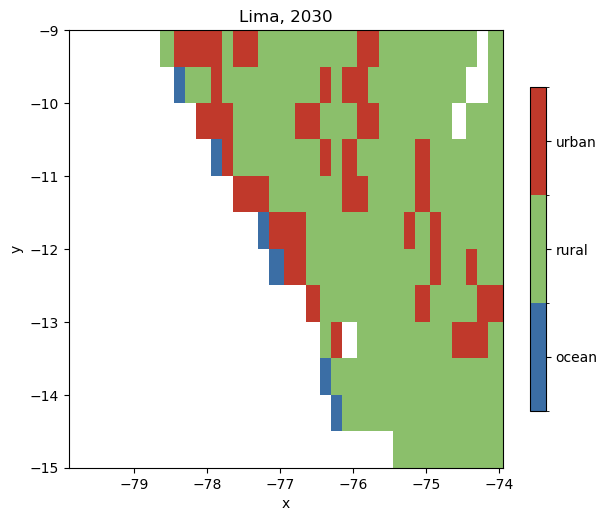

In [21]:
cls_emit = mask_to_emitting(cls, emis)
lima = crop(cls_emit, -80.0, -74.0, -15.0, -9.0)

fig, ax = plt.subplots(figsize=(7, 7))
img = lima.plot.pcolormesh(ax=ax, x="x", y="y", cmap=ListedColormap(["#3b6ea5", "#8bbf6b", "#c0392b"]),
                           norm=BoundaryNorm([-0.5, 0.5, 1.5, 2.5], 3), add_colorbar=False)
bar = fig.colorbar(img, ax=ax, ticks=[0, 1, 2], shrink=0.6)
bar.ax.set_yticklabels(["ocean", "rural", "urban"])
ax.set_aspect("equal")
ax.set_title("Lima, 2030")
plt.show()